# ICAEW Data Analytics Certificate Programme Case Study (Analyst pathway)
## Analysing the data

Welcome back to the Case Study for the ICAEW Data Analytics Certificate Programme (Analyst pathway). 

We have imported and examined the data and identified and resolved any data quality issues already. Now we will use the skills we have learnt within Unit 3. 


We'll use the clean Journals and Sales datasets provided. As our data is now in good shape, we will do some exploratory data analysis to develop our intuitive understanding of the data. The structure of this notebook is as follows.

For the sales data:
- Statistical exploratory analysis
- Visual exploratory analysis 

For the journals data:
- Statistical exploratory analysis
- Visual exploratory analysis


## Setting up the environment

First, we will be using the cleansed datasets provided. These datasets have already been preprocessed and wrangled where the  duplicates have been removed and the missing values have been filled in, where possible.  

In [3]:
# Import the required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set decimals to only be displayed to 2 decimal places
pd.options.display.float_format = '{:.2f}'.format

In [4]:
# Load the clean sales data as sales
sales = pd.read_excel("C:\\Users\\0028773\\OneDrive - DEME\\Documents\\George's Personal Documents\\ICAEW Data Analytics Certificate\\Case Study\\2. Analysing the data - task\\Sales.xlsx")
# Examine the data
print(sales.info())  
display(sales.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59208 entries, 0 to 59207
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          59208 non-null  int64         
 1   Order ID        59208 non-null  object        
 2   Order Date      59208 non-null  datetime64[ns]
 3   Ship Date       59208 non-null  datetime64[ns]
 4   Ship Mode       59208 non-null  object        
 5   Customer ID     59208 non-null  object        
 6   Customer Name   59208 non-null  object        
 7   Segment         59208 non-null  object        
 8   City            59208 non-null  object        
 9   State           59208 non-null  object        
 10  Country         59208 non-null  object        
 11  Region          59208 non-null  object        
 12  Market          59208 non-null  object        
 13  Product ID      59208 non-null  object        
 14  Category        59208 non-null  object        
 15  Su

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,57553,CA-2019-JM15580140-42369,2019-12-31,2020-01-04,Standard Class,JM-155801404,Jill Matthias,Consumer,Loveland,Colorado,...,OFF-FA-3330,Office Supplies,Fasteners,Bagged Rubber Bands,3.02,3,0.20,-0.60,1.17,Medium
1,2334,MX-2019-TD2099582-42369,2019-12-31,2020-01-06,Standard Class,TD-2099582,Tamara Dahlen,Consumer,Juárez,Chihuahua,...,OFF-ST-4261,Office Supplies,Storage,"Fellowes Folders, Blue",35.20,2,0.00,9.12,3.45,Medium
2,38521,IN-2019-MH1778559-42369,2019-12-31,2020-01-06,Standard Class,MH-1778559,Maya Herman,Corporate,Surabaya,Jawa Timur,...,TEC-PH-3793,Technology,Phones,"Cisco Headset, with Caller ID",293.62,4,0.17,88.42,13.57,Medium
3,12146,MX-2019-CM1219093-42369,2019-12-31,2020-01-02,Second Class,CM-1219093,Charlotte Melton,Consumer,Managua,Managua,...,OFF-SU-4982,Office Supplies,Supplies,"Kleencut Ruler, High Speed",72.32,8,0.00,6.40,5.64,Medium
4,1275,ES-2019-JG15805139-42369,2019-12-31,2020-01-05,Standard Class,JG-15805139,John Grady,Corporate,Maidenhead,England,...,FUR-BO-4867,Furniture,Bookcases,"Ikea Stackable Bookrack, Traditional",245.16,2,0.00,90.66,19.21,Medium


In [5]:
# Drop RowID from the sales data
sales = sales.drop(columns=['Row ID'])

In [6]:
# Load the clean journals data as journals
journals = pd.read_excel("C:\\Users\\0028773\\OneDrive - DEME\\Documents\\George's Personal Documents\\ICAEW Data Analytics Certificate\\Case Study\\2. Analysing the data - task\\Journals.xlsx")
# Examine the data
print(journals.info())
display(journals.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Account            3961 non-null   object 
 1   AccountDesc        3961 non-null   object 
 2   TransDesc          3961 non-null   object 
 3   Debit              3961 non-null   float64
 4   Credit             3961 non-null   float64
 5   Period             3961 non-null   object 
 6   JnlNo              3961 non-null   int64  
 7   JnlDesc            700 non-null    object 
 8   Amount             3961 non-null   float64
 9   JnlPrep            3961 non-null   object 
 10  JnlAuth            3961 non-null   object 
 11  JnlDateTime        3961 non-null   object 
 12  JnlPreparerName    3961 non-null   object 
 13  JnlAuthoriserName  3961 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 433.4+ KB
None


,Account,AccountDesc,TransDesc,Debit,Credit,Period,JnlNo,JnlDesc,Amount,JnlPrep,JnlAuth,JnlDateTime,JnlPreparerName,JnlAuthoriserName
0,00-80-8033,Provision for Sales Schemes,ZZX,0.00,9668.59,2019-1,1,Reversed By Jnl 2019-9 Journal No. 277,-9668.59,HV09,AS13,01/01/2019 13:04,Lakeisha Testerman,Jonelle Moseley
1,00-10-1002,Provisions - Trade Sales,XXX,9668.59,0.00,2019-1,1,Reversed By Jnl 2019-9 Journal No. 277,9668.59,HV09,AS13,01/01/2019 13:04,Lakeisha Testerman,Jonelle Moseley
2,00-80-8033,Provision for Sales Schemes,ZZX,0.00,291191.30,2019-1,1,Reversed By Jnl 2019-9 Journal No. 277,-291191.30,HV09,AS13,01/01/2019 13:04,Lakeisha Testerman,Jonelle Moseley
3,00-10-1001,Trade Sale Recycle Scheme,ZZZ,291191.30,0.00,2019-1,1,Reversed By Jnl 2019-9 Journal No. 277,291191.30,HV09,AS13,01/01/2019 13:04,Lakeisha Testerman,Jonelle Moseley
4,00-20-2004,Provision for Obselete Inventory,923,0.00,12848.50,2019-1,10,Reversed By Jnl 2019-4 Journal No. 366,-12848.50,DF18,TC01,30/01/2019 09:56,Jon Mckinley,Johnny Hevey


# Exploratory Data Analysis of the sales data

By performing Exploratory Data Analysis (EDA) on the sales data, we can understand exactly how the company is performing. We can see whether it appears to be profitable and a good investment. We can also pinpoint any areas that may be of interest to management. It is good practice when performing EDA to gain an overall picture of the data and focus in on key areas of interest, before performing more in-depth analysis.

In respect to the sales data, we will seek to understand whether the company's sales suggests that the company would be a good investment. This will focus on the profitability and the volume of sales of the company. As well as describing current performance, we should be mindful of ways to improve performance as the basis for recommendations to management. 

## Statistical exploratory analysis

By examining the summary statistics for the sales data, we can gain an initial impression of the sales and performance.

We looked at summary statistics in Module 2 of Unit 3: Analysing the Data, where we examined statistical exploratory data analysis. If you purchased the learning and certificate Analyst Pathway, we recommend you revisit this content if you are struggling to complete these tasks.


The following is assessed in the assessment.


We need to use the clean sales dataset provided to examine the summary statistics of each sales order by looking at the description of the overall sales data.


In [7]:
# Examine the summary statistics of the sales data
sales.describe()

,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Cost
count,59208,59208,59208.00,59208.00,59208.00,59208.00,59208.00
mean,2017-12-27 03:56:29.866234368,2017-12-31 03:15:07.661126912,254.97,3.46,0.15,28.14,24.79
min,2015-01-01 00:00:00,2015-01-02 00:00:00,0.44,1.00,0.00,-6599.98,1.00
25%,2016-11-06 00:00:00,2016-11-09 00:00:00,29.28,2.00,0.00,-1.57,2.54
50%,2018-03-16 00:00:00,2018-03-19 00:00:00,83.66,3.00,0.00,8.16,7.35
75%,2019-03-31 00:00:00,2019-04-03 06:00:00,253.80,5.00,0.20,36.93,22.47
max,2019-12-31 00:00:00,2020-01-07 00:00:00,22638.48,14.00,0.85,8399.98,933.57
std,NaN,NaN,519.89,2.35,0.22,177.51,54.46


##### <b>Please take a note of the mean profit per sales order.</b>

<i>Select here to type your answer: 28.14

In addition to looking at the company's performance across the 4 years of data we have available, we may want to explictly examine its performance for each year individually.

We learnt how to add new columns and to group by and aggregate data in Module 1 of Unit 3: Analysing the Data. If you purchased the learning and certificate Analyst Pathway, we strongly recommend you revisit this content if you are struggling to complete these tasks.

In [10]:
# Load datetime package required
import datetime as dt

# Add a column called Year to the sales data that contains the year of each sales order
sales['Year'] = sales['Order Date'].dt.year

In [15]:
# Create a dataset called salesyears containing the totals for each year

salesyears = (sales.groupby('Year', as_index=False).sum(numeric_only=True))

The following is assessed in the assessment.

To obtain the profit margin for each year, we must first aggregate the data by the year of the order date to get the total. To do this we need to add a new column containing the year of the sales order. We can select Order Date and then use dt.year to select the year only.

In [20]:
# Add a column Profit Margin to salesyears
salesyears['Profit Margin'] = salesyears['Profit'] / salesyears['Sales']

# Examine the data
print(salesyears.head())

   Year      Sales  Quantity  Discount    Profit  Shipping Cost  Profit Margin
0  2015 2453799.82     26556   1596.29 198548.53      109742.76           0.08
1  2016 2259450.90     31443   1333.39 248940.81      245211.35           0.11
2  2017 2677438.69     38111   1548.77 307415.28      284590.82           0.11
3  2018 3405746.45     48136   1935.52 406935.23      365956.74           0.12
4  2019 4299865.87     60622   2512.04 504165.97      462326.79           0.12


##### <b>Please take a note of the profit margin for the company's sales for the previous year.</b>

<i>Select here to type your answer:12%

The company's previous year's performance is of specific interest to us, from an investment perspective. By only looking at the data for last year, we can perform more deep dive analysis to see how the previous year's performance differs depending on factors such as region or category of product being sold. This will help us identify areas that show promise for investment and problem areas that may be a cause for concern.

We examined how to filter, aggregate and sort data in Module 1 of Unit 3: Analysing the Data. If you purchased the learning and certificate Analyst Pathway, we strongly recommend you revisit this content if you are struggling to complete these tasks.

In [21]:
# Create a subset of the data called pysales that only contains the previous year's, 2019, data
pysales = sales[sales['Year'] == 2019]

In [25]:
# Using the previous year's sales, create a new dataset called salesregions that is the total sales and profits by region
salesregions = (
    pysales
    .groupby('Region', as_index=False)
    .agg({
        'Sales': 'sum',
        'Profit': 'sum'
    })
)

The following is assessed in the assessment.

To isolate records in 2019, we must first filter our sales dataset to create a new dataset only for 2019 sales. There are a variety of ways to do this. One way would be to use the query command with the condition ‘Year==2019’. We then want to identify which region produced the highest total profits.

In [28]:
# Identify the highest performing regions in profits in 2019
salesregions.sort_values(by='Profit', ascending=False)

,Region,Sales,Profit
21,Western Europe,602860.95,74775.48
16,Southern Asia,297363.17,56006.55
7,Eastern Asia,266148.17,53039.18
3,Central America,389522.94,48051.64
22,Western US,250632.53,43900.63
9,Eastern US,213239.42,33195.35
17,Southern Europe,219805.39,33032.14
12,Oceania,362429.89,31431.58
8,Eastern Europe,120204.72,28519.98
10,North Africa,90402.90,21740.13


##### Please take a note of the most profitable region in 2019.

<i>Select here to type your answer: Western Europe

## Statistical tests

Now that we have an initial impression of the data, we can use statistical tests to check any hypothesis or assumptions we have about the data. We are interested to determine if these are statistically significant. In particular, we can examine the profitability of the company by region in line with our assumptions. We have seen that Western Africa and Western Asia both produced negative profits in 2019. Now we can exmaine if these profits differ signficantly.

In [32]:
# Create a sample for the t-test called pysales_waf of the 2019 sales orders for Western Africa
pysales_waf = pysales[pysales['Region'] == 'Western Africa']

In [33]:
# Create a sample for the t-test called pysales_was of the 2019 sales orders for Western Asia
pysales_was = pysales[pysales['Region'] == 'Western Asia']

In [34]:
# Import the stats library from the SciPy package
from scipy import stats 

# Perform a 2 sample t-test on the company's profits for Western Africa and Western Asia
stats.ttest_ind(
    pysales_waf['Profit'],
    pysales_was['Profit'],
    equal_var=False
)

TtestResult(statistic=np.float64(-0.5357973996645063), pvalue=np.float64(0.5922328503983509), df=np.float64(887.3343785362089))

In [31]:
# Examine any other areas of interest


## Visual exploratory analysis

We have examined the spread of the data through the use of summary statistics. However, this only gives us a high level overview of the numerical fields in the data. In order to gain a deeper impression of the spread of the data, including considering any categorical fields, we can use visualisations. Through visualising the sales data, we can see how the sales orders are distributed.

We practised creating basic visualisations, including barplots and boxplots, in Module 3 of Unit 3: Analysing the Data. If you purchased the learning and certificate Analyst Pathway, we strongly recommend you revisit this content if you are struggling to complete these tasks.

In [35]:
# Import the required visualisation packages
import matplotlib.pyplot as plt
import seaborn as sns


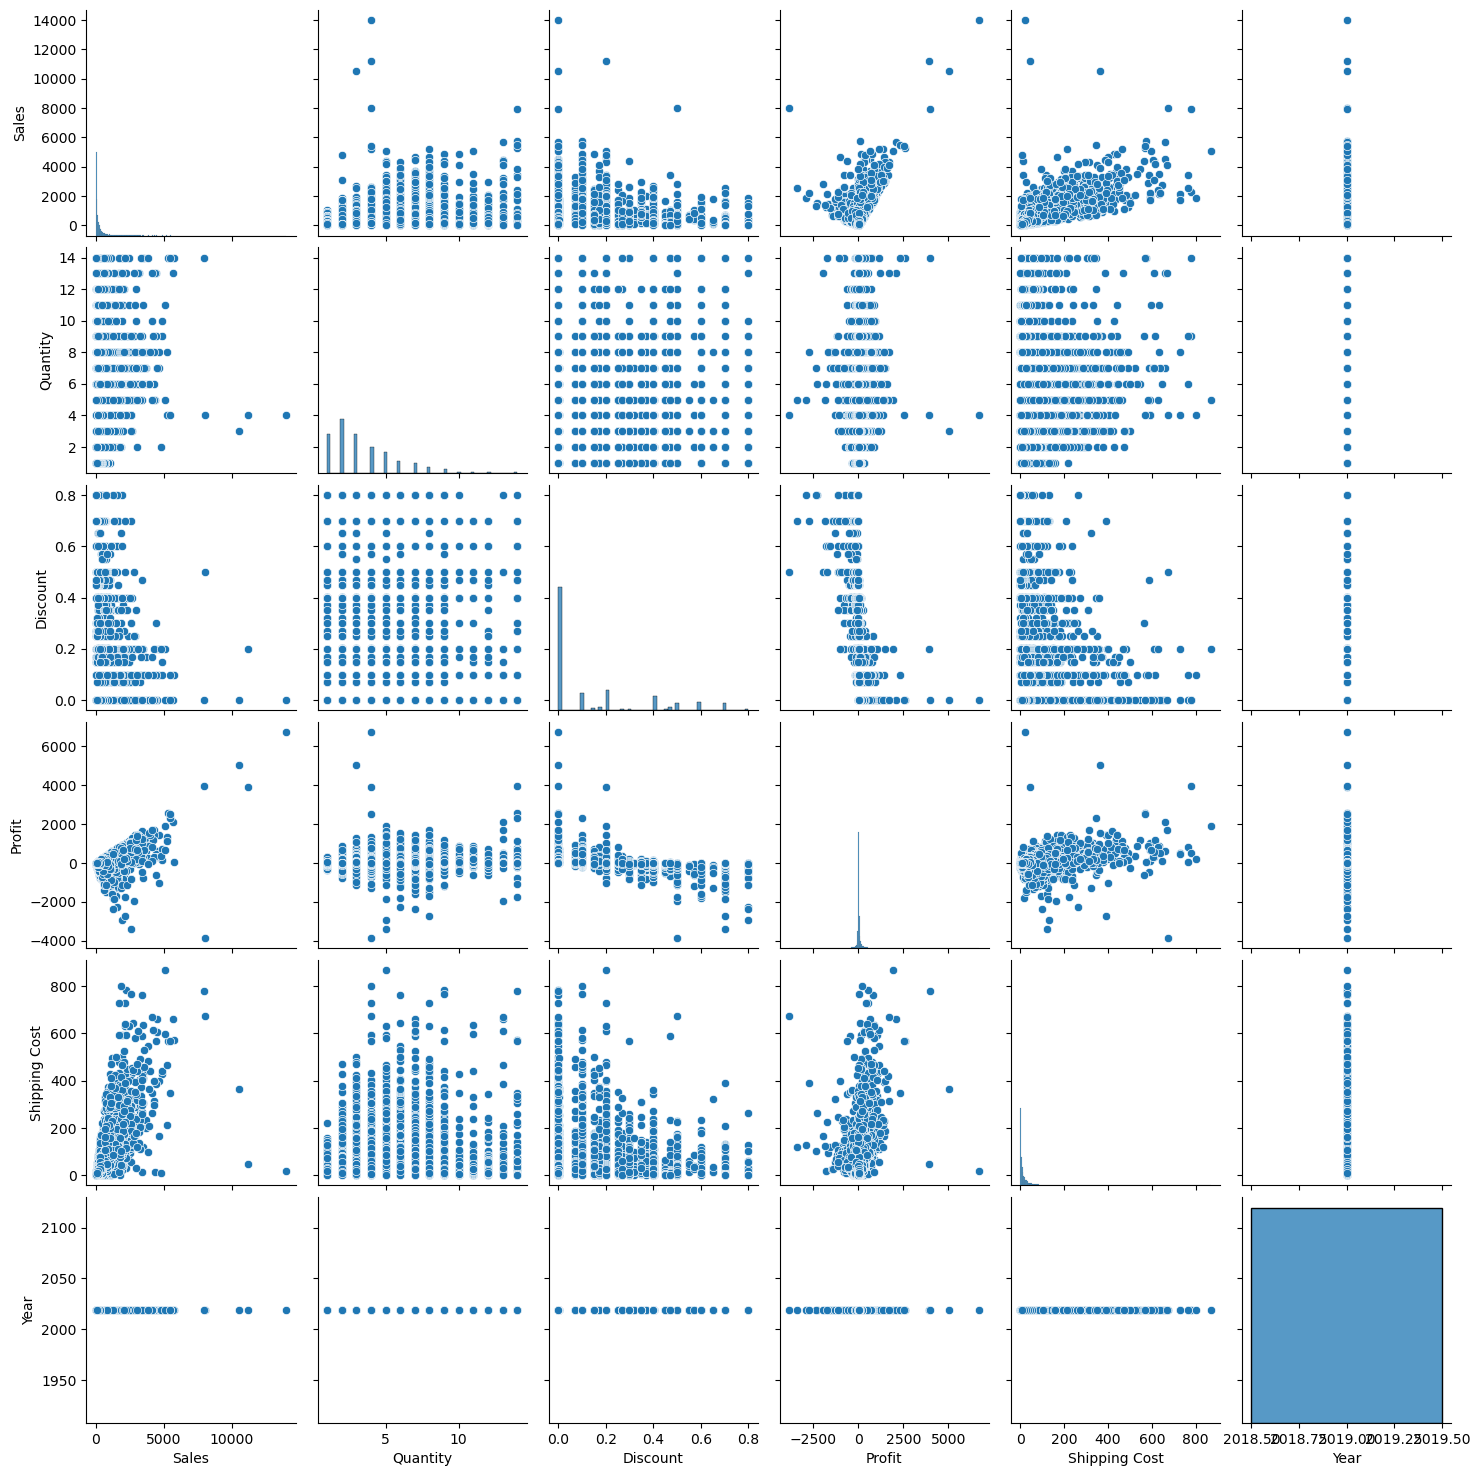

In [36]:
# Create a pairs plot of the 2019 sales data
sns.pairplot(pysales.select_dtypes(include='number'))
plt.show()



This plot gives us an initial distribution of the sales orders in relation to the numerical fields of the dataset. In particular, we are interested in analysing the sales and profits of the company. Therefore, additional visualisations on these areas are useful to help us understand more about the company's performance.

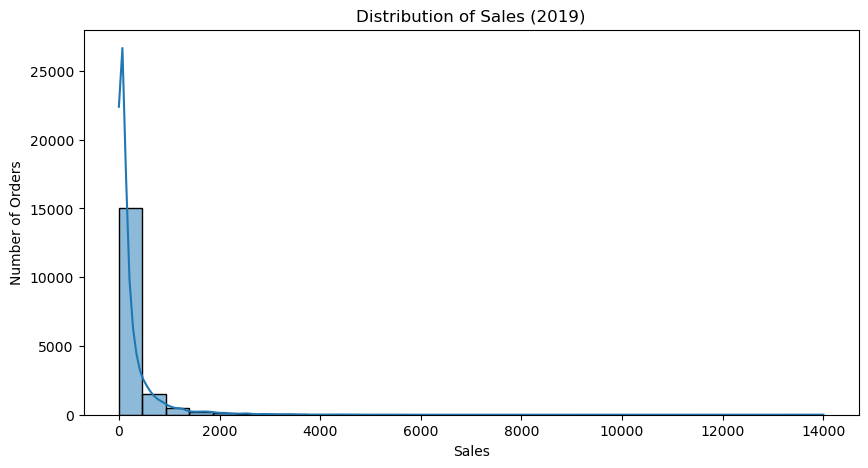

In [39]:
# Create a visualisation showing the distribution of sales in 2019

plt.figure(figsize=(10, 5))
sns.histplot(data=pysales, x='Sales', bins=30, kde=True)
plt.title('Distribution of Sales (2019)')
plt.xlabel('Sales')
plt.ylabel('Number of Orders')
plt.show()



In addition to understanding what the profits and sales are for the company in question, we also want to be able to comment on why these values are what they are. For instance, as a potential investor, we would like to identify profitable parts of the business with a large volume of sales and unprofitable parts of the business that may be a cause for concern.

The following is assessed in the assessment.

To see which category of products has the smallest mean profit in 2019, we can create a barplot using the Seaborn package with the 2019-only data that we previously created.

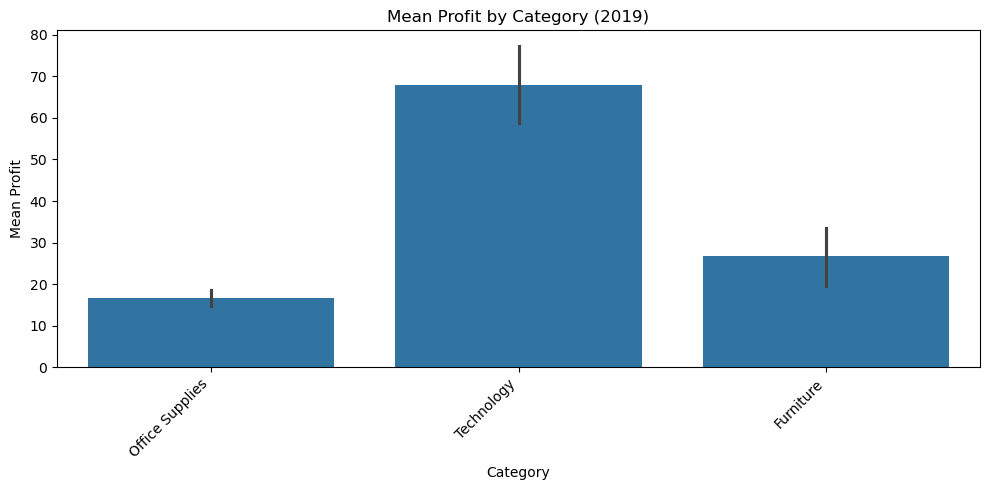

In [40]:
# Create a barplot of how profit varies by category for 2019

plt.figure(figsize=(10, 5))
sns.barplot(data=pysales, x='Category', y='Profit', errorbar='ci')
plt.title('Mean Profit by Category (2019)')
plt.xlabel('Category')
plt.ylabel('Mean Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



##### <b>Please take a note of the category of products with the smallest mean profit in 2019.</b>

<i>Select here to type your answer: Office Supplies

The following is assessed in the assessment.

We can examine boxplots of profit by region using our 2019-only data with the Seaborn package. The catplot command produces boxplots by region. We will have to specify that we want to visualise a boxplot with outliers excluded using parameters within this command.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'Western US'),
  Text(1, 0, 'Central America'),
  Text(2, 0, 'Southeastern Asia'),
  Text(3, 0, 'Northern Europe'),
  Text(4, 0, 'Eastern Asia'),
  Text(5, 0, 'Western Europe'),
  Text(6, 0, 'Eastern Africa'),
  Text(7, 0, 'Southern Asia'),
  Text(8, 0, 'Western Asia'),
  Text(9, 0, 'Caribbean'),
  Text(10, 0, 'North Africa'),
  Text(11, 0, 'South America'),
  Text(12, 0, 'Eastern Europe'),
  Text(13, 0, 'Central Africa'),
  Text(14, 0, 'Southern Europe'),
  Text(15, 0, 'Central US'),
  Text(16, 0, 'Eastern US'),
  Text(17, 0, 'Canada'),
  Text(18, 0, 'Western Africa'),
  Text(19, 0, 'Oceania'),
  Text(20, 0, 'Southern US'),
  Text(21, 0, 'Central Asia'),
  Text(22, 0, 'Southern Africa')])

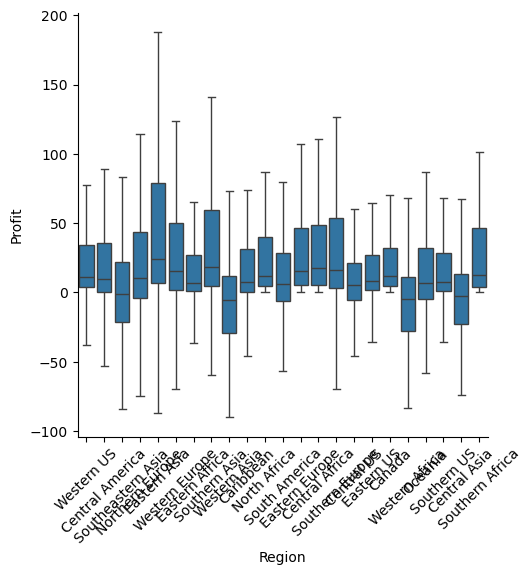

In [42]:
# Create boxplots of profit by region for 2019 with the outliers excluded
sns.catplot(data=pysales, x='Region', y='Profit', kind='box', showfliers=False)
plt.xticks(rotation=45)


##### <b>Please take a note of the region with the greatest InterQuartile Range in profits for 2019.</b>

<i>Select here to type your answer: Eastern Asia

<Axes: xlabel='Discount', ylabel='Profit'>

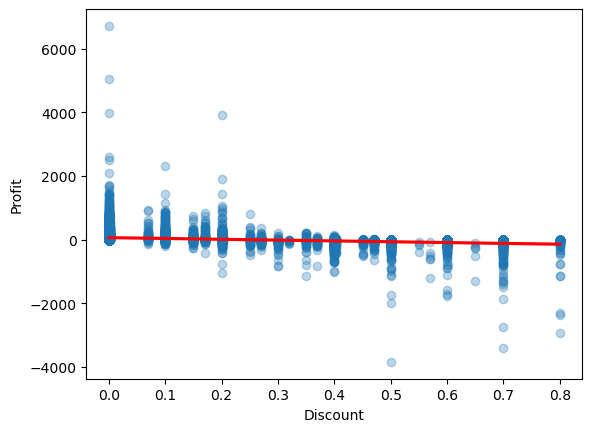

In [43]:
# Investigate the impact of discount on profit

sns.regplot(data=pysales, x='Discount', y='Profit', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

# EDA of the journals data

By performing EDA on the journals data, we can examine the company's control environment, specifically looking at how journals are raised and posted. We can also identify any occasions that deviate from expectations, which might indicate a weakness of controls or potentially fraudalent behaviour. Therefore, EDA can help us to obtain a high-level view of the control environment surrounding journals. We can also focus in any anomalies identified.

Any potential weaknesses in the control environment identified through the journal postings can be significant from an investment perspective. These weaknesses can undermine the confidence that investors have in the validity of the financial performance and results posted in the financial statements. It is also indicative of how management have prioritised risk within the business. 

## Statistical exploratory analysis

By examining summary statistics for the journals data, we can gain an initial impression of the journals and the financial reporting processes. 

In [44]:
# Examine the summary statistics of the journals data
journals.describe()

,Debit,Credit,JnlNo,Amount
count,3961.00,3961.00,3961.00,3961.00
mean,31565.90,31565.90,279.04,0.00
std,115849.96,115849.96,160.83,169810.91
min,0.00,0.00,1.00,-1065322.15
25%,0.00,0.00,136.00,-4162.38
50%,0.42,0.00,283.00,0.42
75%,4162.38,4162.38,430.00,4162.38
max,1065322.15,1065322.15,538.00,1065322.15


In addition to a high-level view of the data, we can perform deep dive analysis to identify patterns in postings by journal number or employee. This can provide us with insight in areas such as segregration of duties.

We practised adding columns (including Absolute Amount) and aggregating data in Module 1 of Unit 3: Analysing the Data. If you purchased the learning and certificate Analyst Pathway, we strongly recommend you revisit this content if you are struggling to complete these tasks.

In [45]:
# Load the numpy package
import numpy as np

# Add a column to the journals dataset with the absolute value of amount called AbsAmount
journals['AbsAmount'] = journals['Amount'].abs()

The following is assessed in the assessment.

First, we need to add an additional column to our clean journals dataset by using the abs() command in the numpy package on our Amount column in the journals data. Then we can aggregate and sum the data to get the total absolute amount.

In [51]:
# Sum the absolute amount of the journal entries by employee who authorised them 
authoriser_sums = journals.groupby('JnlAuthoriserName')['AbsAmount'].sum()
authoriser_sums.sort_values(ascending=False)

JnlAuthoriserName
King Forkey         68526019.60
Ray Johansson       43182177.66
Johnny Hevey        42987542.92
Jonelle Moseley     39665165.38
Lizbeth Arvin       30085155.66
Maye Ahl            25619026.10
Name: AbsAmount, dtype: float64

##### <b>Please take a note of the employee who authorised journal entries with the total greatest value.</b>

<i>Select here to type your answer: King Forkey

In [52]:
# Examine any other area of interest



## Visual exploratory analysis

We have examined the spread of the data through the use of summary statistics. However, this only gives us a high level overview of the numerical fields in the data. In order to gain a deeper impression of the spread of the data, including the identification of any potential anomalous journals, we can use visualisations. 

In addition to an overall picture of how the company's journals are managed, we can perform more deep dive analysis to see how journals differ depending on the employee responsible for the posting. 

We examined how to visualise and interpret box plots in Module 3 of Unit 3: Analysing the Data. If you purchased the learning and certificate Analyst Pathway, we strongly recommend you revisit this content if you are struggling to complete these tasks.

The following is assesed in the assessment.

We can identify how many journal entries the Financial Controller prepared by creating a countplot using the Seaborn package of the journal preparer name. This will produce bar charts of each preparer with the count of journal entries they prepared.

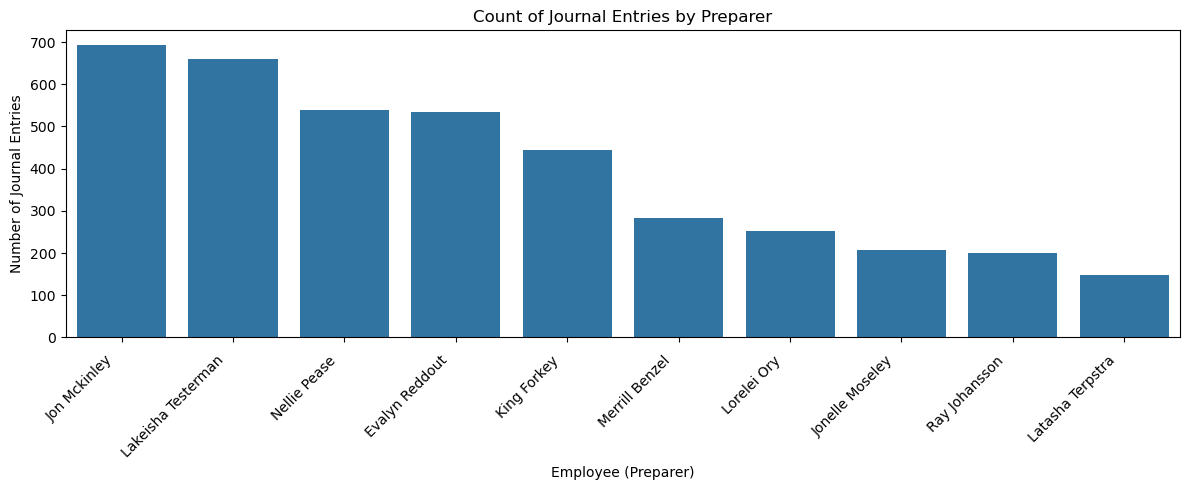

JnlPreparerName
Jon Mckinley            693
Lakeisha Testerman      660
Nellie Pease            539
Evalyn Reddout          535
King Forkey             444
Merrill Benzel          284
Lorelei Ory             253
Jonelle Moseley         206
Ray Johansson           199
Latasha Terpstra        148
Name: count, dtype: int64

In [56]:
# Create a bar chart of the count of records by employee who prepared the journal entries

plt.figure(figsize=(12, 5))
sns.countplot(
    data=journals,                      # <-- your journal entries dataframe
    x='JnlPreparerName',              # <-- change to your exact preparer column name
    order=journals['JnlPreparerName'].value_counts().index
)
plt.title('Count of Journal Entries by Preparer')
plt.xlabel('Employee (Preparer)')
plt.ylabel('Number of Journal Entries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

journals['JnlPreparerName'].value_counts()

##### <b>Please take a note of the number of journal entries the Financial Controller has prepared.</b>

<i>Select here to type your answer: 206

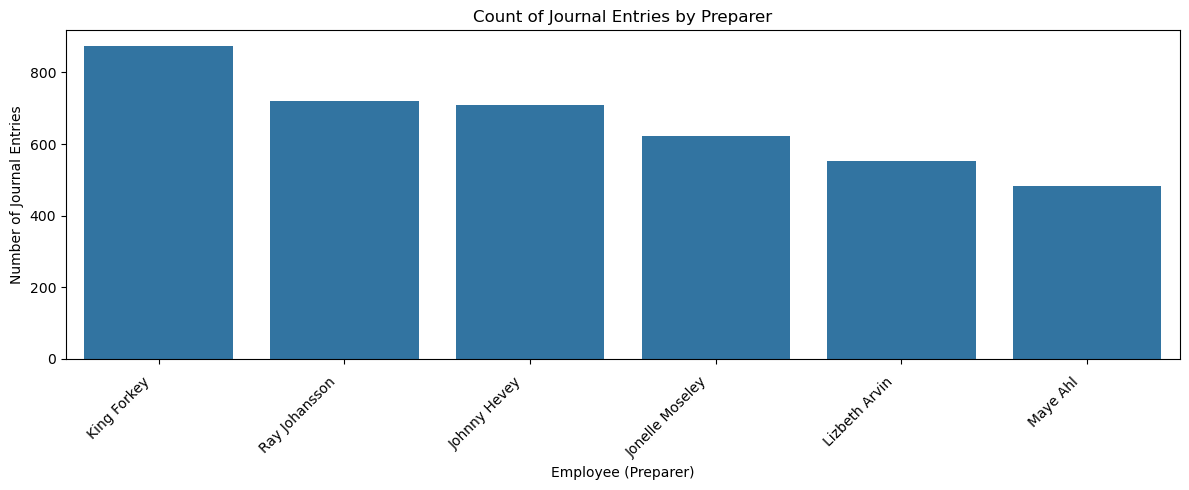

JnlAuthoriserName
King Forkey          874
Ray Johansson        721
Johnny Hevey         709
Jonelle Moseley      623
Lizbeth Arvin        552
Maye Ahl             482
Name: count, dtype: int64

In [57]:
# Create a bar chart of the count of records by employee who authorised the journal entries
plt.figure(figsize=(12, 5))
sns.countplot(
    data=journals,                      # <-- your journal entries dataframe
    x='JnlAuthoriserName',              # <-- change to your exact preparer column name
    order=journals['JnlAuthoriserName'].value_counts().index
)
plt.title('Count of Journal Entries by Preparer')
plt.xlabel('Employee (Preparer)')
plt.ylabel('Number of Journal Entries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

journals['JnlAuthoriserName'].value_counts()


##### Assessment guidance

You are ready to take the assessment.

Remember, you should have fully completed your task and recorded your answers in Jupyter Notebook before moving on to the assessment. You can keep your Jupyter Notebook open in a separate browser window to refer to as you take the assessment. 

You will receive a score following completion of the assessment. If you have scored below the target mark of 60% for the section, you are recommended to refresh your knowledge in the course content (if purchased) and rework your Jupyter Notebook before re-attempting the assessment. You have a maximum of three assessment attempts.

You should aim to achieve a target score of 60% in each section of the case study. To pass the case study and be awarded the ICAEW Certificate, you are required to achieve a pass mark of 60% overall, averaged over all five sections, so do not be disheartened if you score below 60% in any one section, as a higher score in one or more of the other sections will contribute to the overall pass mark of 60%.

IMPORTANT: When submitting to the assessment portal, please do not navigate away from it until you have submitted all of your answers for that task. In between any of your 3 assessment attempts (but not during an attempt) you may navigate back to the course content, if you have purchased it, to refresh your knowledge and revisit your Jupyter Notebook to rework your analysis.